# 07 Final Report — Six Decades of the Billboard Hot 100 (1960-2019)

**Author:** Fu Wei Hsu
**Pipeline:** Python (pandas, statsmodels, scikit-learn, matplotlib) — 01-06 `_auto.ipynb`

In [1]:
import os
import base64
from IPython.display import Image, display, HTML

DATA_DIR = "../Data"

def show(filename, width=900):
    display(Image(filename=os.path.join(DATA_DIR, filename), width=width))

def show_row(filenames, height_px=380):
    """Display multiple images side by side, all scaled to the same height
    (width follows each image's own aspect ratio, so widths may differ but
    heights and titles line up). Inline base64, no path-resolution issues."""
    imgs_html = []
    for fn in filenames:
        with open(os.path.join(DATA_DIR, fn), 'rb') as f:
            b64 = base64.b64encode(f.read()).decode('ascii')
        imgs_html.append(f'<img src="data:image/png;base64,{b64}" style="height:{height_px}px; width:auto; display:block;">')
    display(HTML('<div style="display:flex; align-items:flex-start; gap:16px;">' + "".join(imgs_html) + "</div>"))

## 1. Introduction

Popular music is more than entertainment — it is a mirror of its time, reflecting the cultural, social, and technological shifts of each era. This study analyzes six decades of the Billboard Hot 100 (1960-2019), combining chart data with Spotify audio features and genre/lyrical metadata, to explore what defines a "hit" and how that definition has changed over time.

### Research Questions

- **RQ1:** How has the genre distribution of Billboard Hot 100 songs changed across decades?
- **RQ2:** How have the emotional dimensions of popular music evolved across six decades, and what cultural or technological shifts might explain these changes?
- **RQ3:** Does the rise of speechiness in popular music reflect the mainstreaming of Hip-Hop?
- **RQ4:** Which audio features are most strongly associated with a song's chart performance?

## 2. Data & Methodology

### 2.1 Datasets

| Dataset | Source | Records | Role |
|:---|:---|:--:|:---|
| D1 — Billboard Hot 100 | Kaggle (dhruvildave) | 330,087 | Weekly chart records, 1958-2021 |
| D2 — Spotify Hit Predictor | Kaggle (theoverman) | 41,106 | Audio features + Hit/Flop labels, 50/50 balanced |
| D3 — Music Dataset 1950-2019 | Kaggle (saurabhshahane) | 28,372 | Genre classification + lyrical sentiment |

### 2.2 Pipeline Architecture

Every notebook in the pipeline (`01`-`06_auto.ipynb`) follows the same three-layer design — this is a pipeline-wide convention, not something specific to any one notebook. The example below (`build_modeling_dataset()`, `evaluate_classifier()`) is drawn from `06_modeling_auto.ipynb` purely to illustrate the pattern concretely; each of the other notebooks defines its own CONFIG and its own Engine-layer functions following the same structure.

| Layer | What it holds |
|---|---|
| **CONFIG** | The things that change: file paths, feature lists, split ratios, random seeds |
| **Engine** | Shared functions called repeatedly (e.g. `build_modeling_dataset()`, `evaluate_classifier()` in 06) so the same logic is never pasted twice |
| **Steps** | Numbered, narrated steps that call the Engine and print/plot results |

`analysis_base` (used for RQ1-RQ3) is built by joining D1+D2+D3, keeping only rows with a matched D2 `target`, filtered to 1960-2019 — **262,737 records**. `model_df` (used for RQ4) uses raw D2 directly, not the joined dataset — see Section 6 for why.

### 2.3 Analytical Approach

- **RQ1-RQ3:** Exploratory trend analysis across six decades, cross-checked with counterfactual tests where a causal claim was being considered
- **RQ4:** Binary classification (Logistic Regression + Random Forest) on Spotify audio features, explanatory not predictive — see Section 7
- **Scope:** U.S. market only, 1960-2019, to keep consistent coverage across all three datasets

## 3. Results — RQ1: Genre Distribution Across Decades

- Pop has consistently dominated the Billboard Hot 100, rising from **61.4%** (1960s) to **78.4%** (2010s).
- Rock emerged as a major force in the 1970s-80s, peaking at **34.3%** (1980s), before declining sharply to **4.3%** by the 2010s.
- Blues, which accounted for **15.1%** of the chart in the 1960s, had fallen to essentially zero (**0.2%**) by the 2010s.


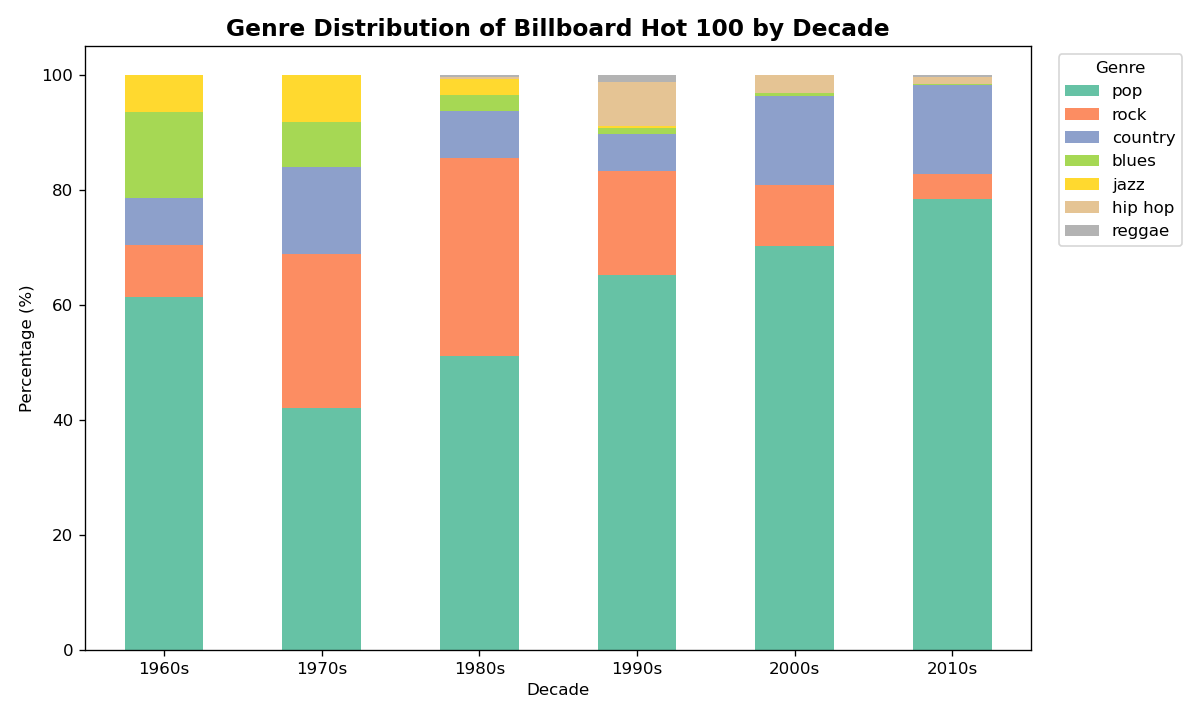
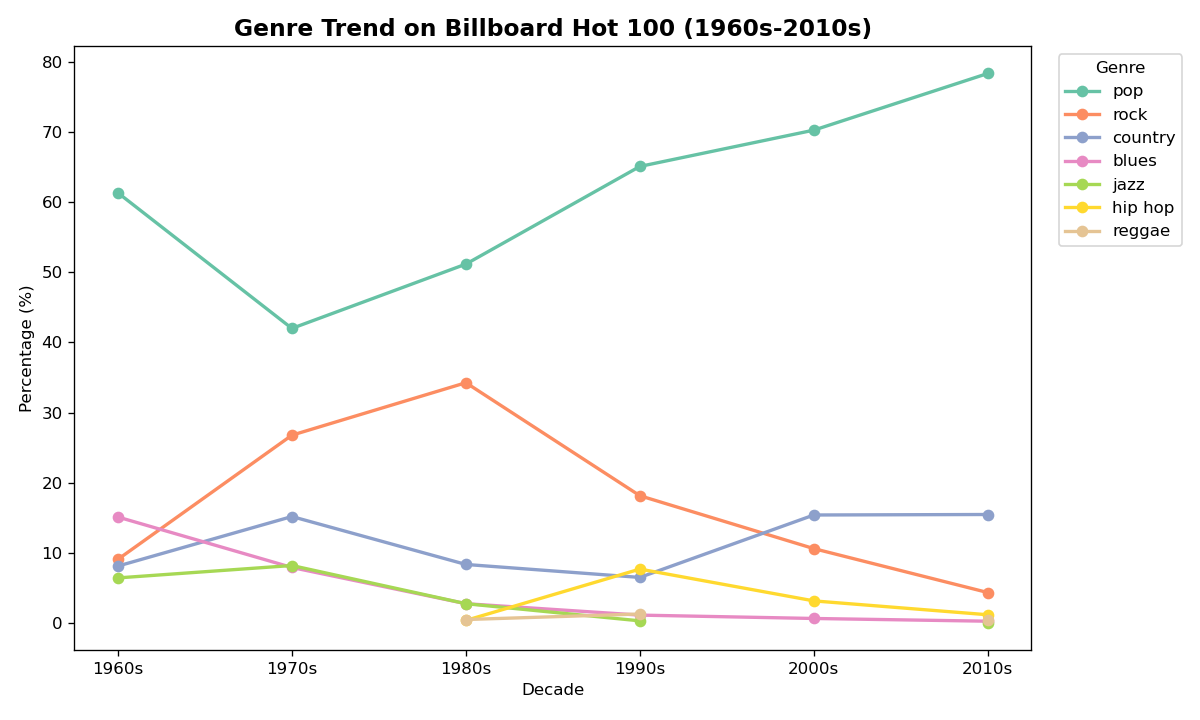

In [2]:
show_row(["rq1_genre_stacked_bar.png", "rq1_genre_line.png"])

## 4. Results — RQ2: Emotional Evolution of Popular Music

Across the five audio features tracked, **Acousticness** declined sharply, while **Energy** and **Danceability** steadily increased. This shift reflects a transition from acoustic instrumentation to synthetic production, alongside the growing dominance of high-energy and dance-oriented rhythms.

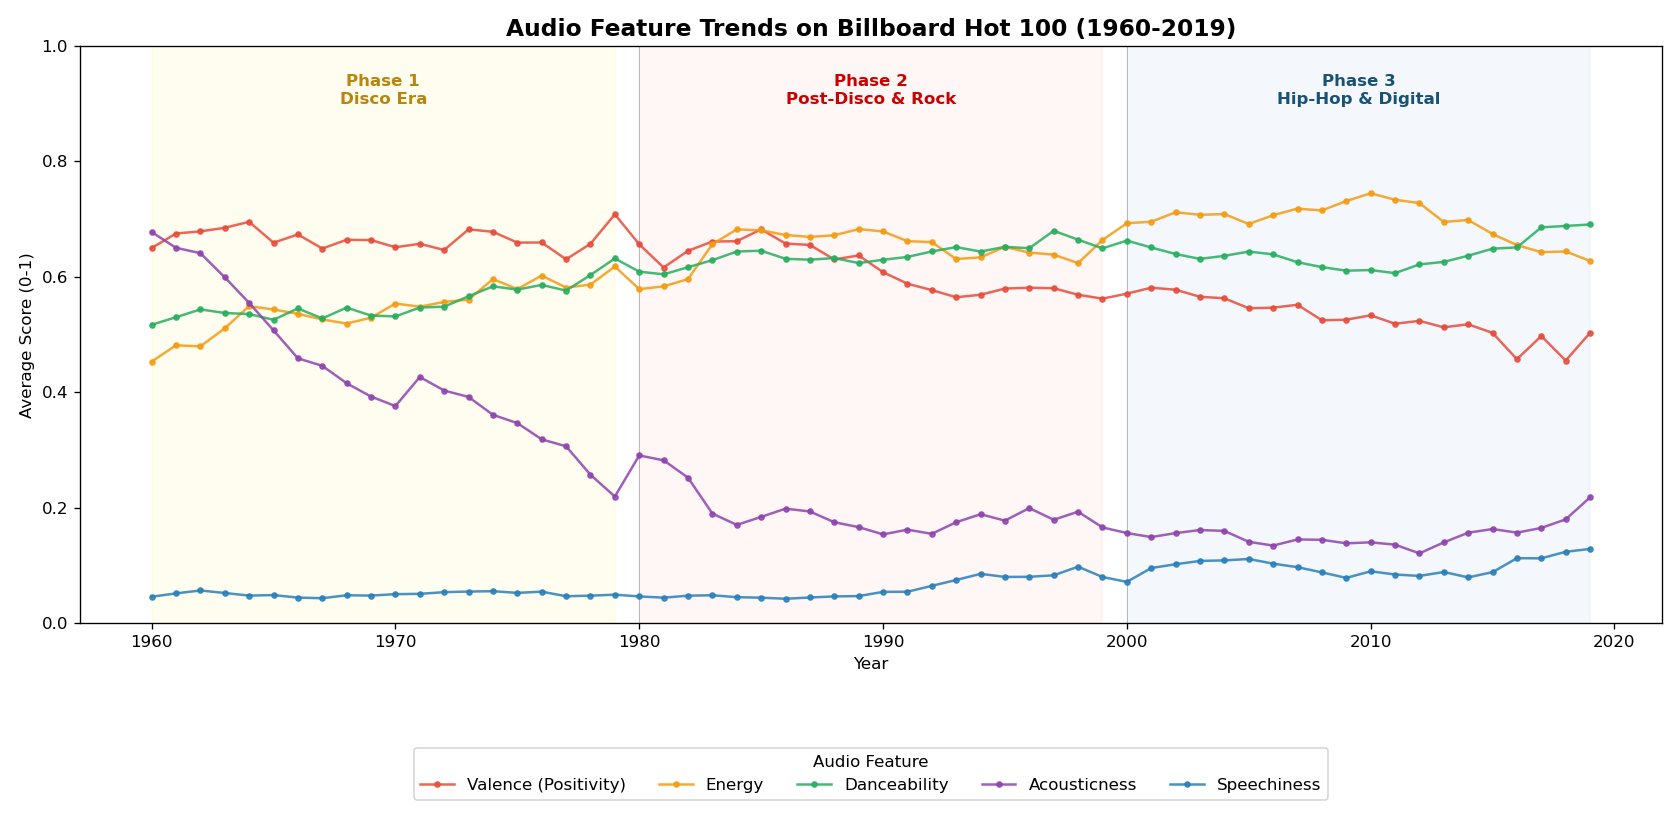

In [3]:
show("rq2_five_features_trend.png")

the most striking pattern is the **divergence between Valence and Energy**: 

- **Valence** fell from **0.650** (1960) to **0.503** (2019), a ~22.6% decline.
- **Energy** rose from **0.453** (1960) to **0.628** (2019) over the same period.
> As a result, **Modern popular music since 1985** is not simply "sadder", presenting a darker emotional tone balanced by a more energetic and forceful presence.

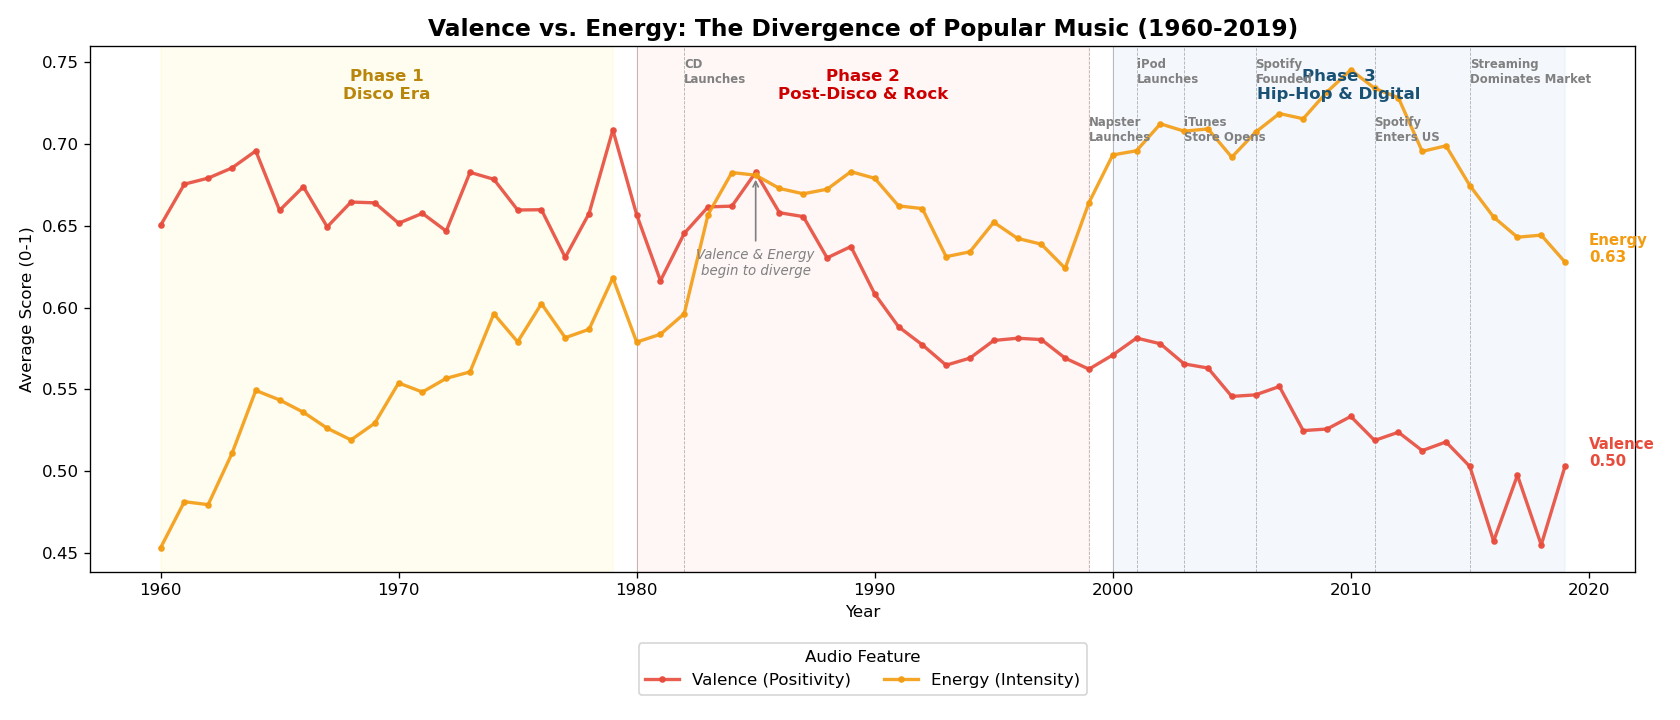

In [4]:
show("rq2_valence_energy_divergence.png")

### Longest-Charting Song per Decade

For each decade, the single song that spent the most weeks on the Billboard Hot 100, alongside its Acousticness, Valence, and Energy

| Decade | Song | Artist | Weeks on Chart | Acousticness | Valence | Energy |
|---|---|---|--:|--:|--:|--:|
| 1960s | The Twist | Chubby Checker | 39 | 0.202 | 0.937 | 0.638 |
| 1970s | I Go Crazy | Paul Davis | 40 | 0.259 | 0.271 | 0.457 |
| 1980s | Tainted Love | Soft Cell | 43 | 0.558 | 0.626 | 0.450 |
| 1990s | How Do I Live | LeAnn Rimes | 69 | 0.128 | 0.258 | 0.462 |
| 2000s | I'm Yours | Jason Mraz | 76 | 0.957 | 0.307 | 0.107 |
| 2010s | Radioactive | Imagine Dragons | 87 | 0.106 | 0.236 | 0.784 |

## 5. Results — RQ3: Speechiness and the Mainstreaming of Hip-Hop

**Speechiness** — Spotify's measure of spoken-word quality — rose from **0.0461 in 1960** to **0.1289 in 2019**, a **179.6%** increase, one of the most dramatic structural shifts in the chart's sonic profile. Genre-level analysis confirms Hip-Hop drives this: its average speechiness (**0.2325**) dwarfs every other genre.

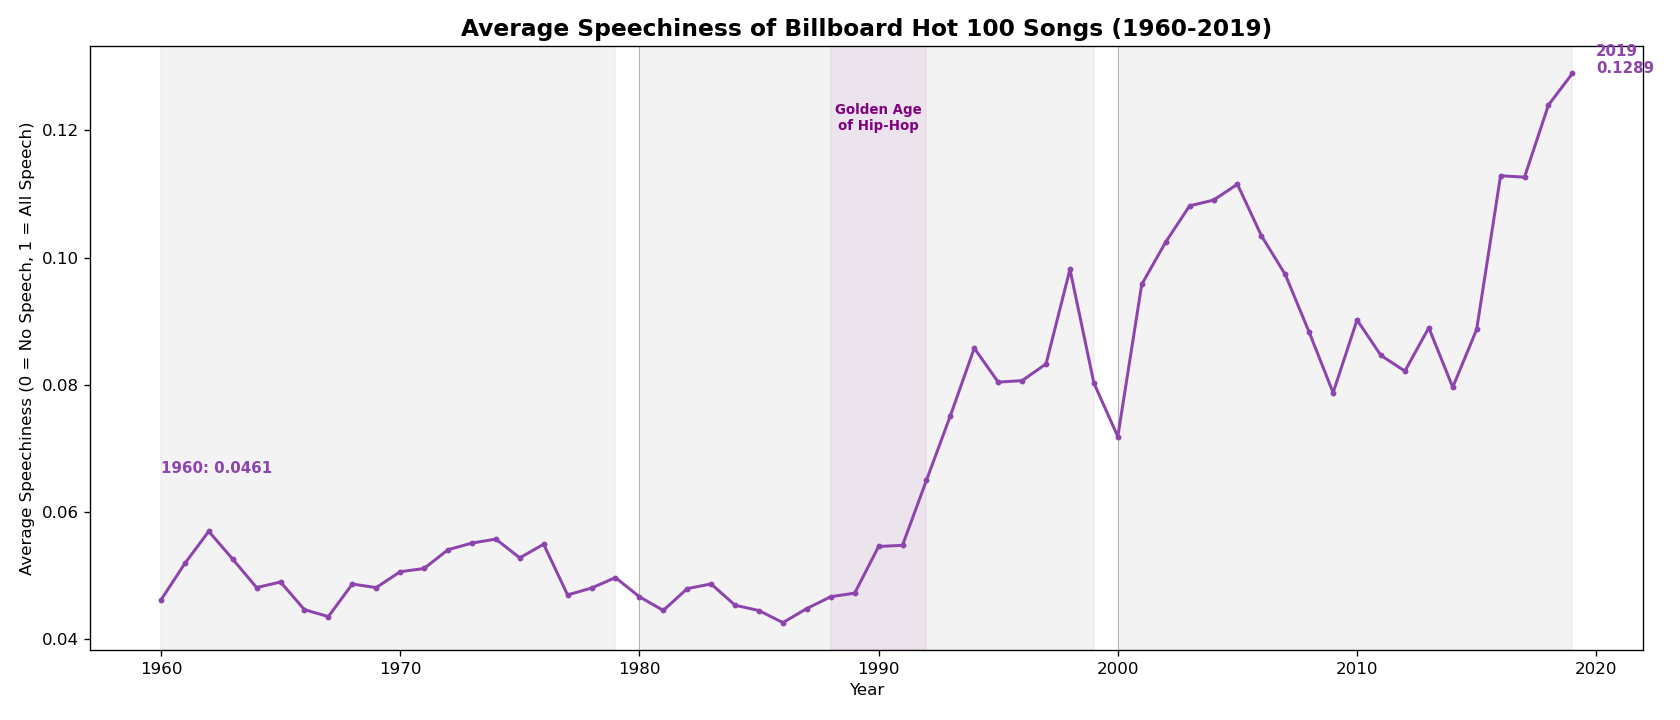

In [5]:
show("rq3_speechiness_trend.png")

### Where the Rise Comes From

Hip-Hop's genre profile stands apart from every other genre on both measures that matter here: **speechiness (0.233) and acousticness (0.092)** — far more spoken-word, far less acoustic than Pop (**speechiness 0.069, acousticness 0.224**) or any of the other five genres tracked.

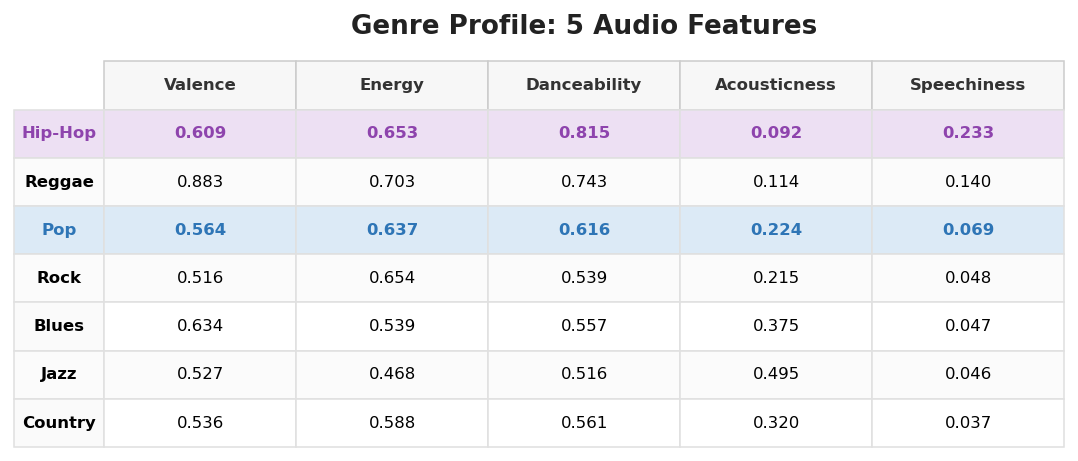

In [6]:
show("rq3_genre_profile.png", width=760)

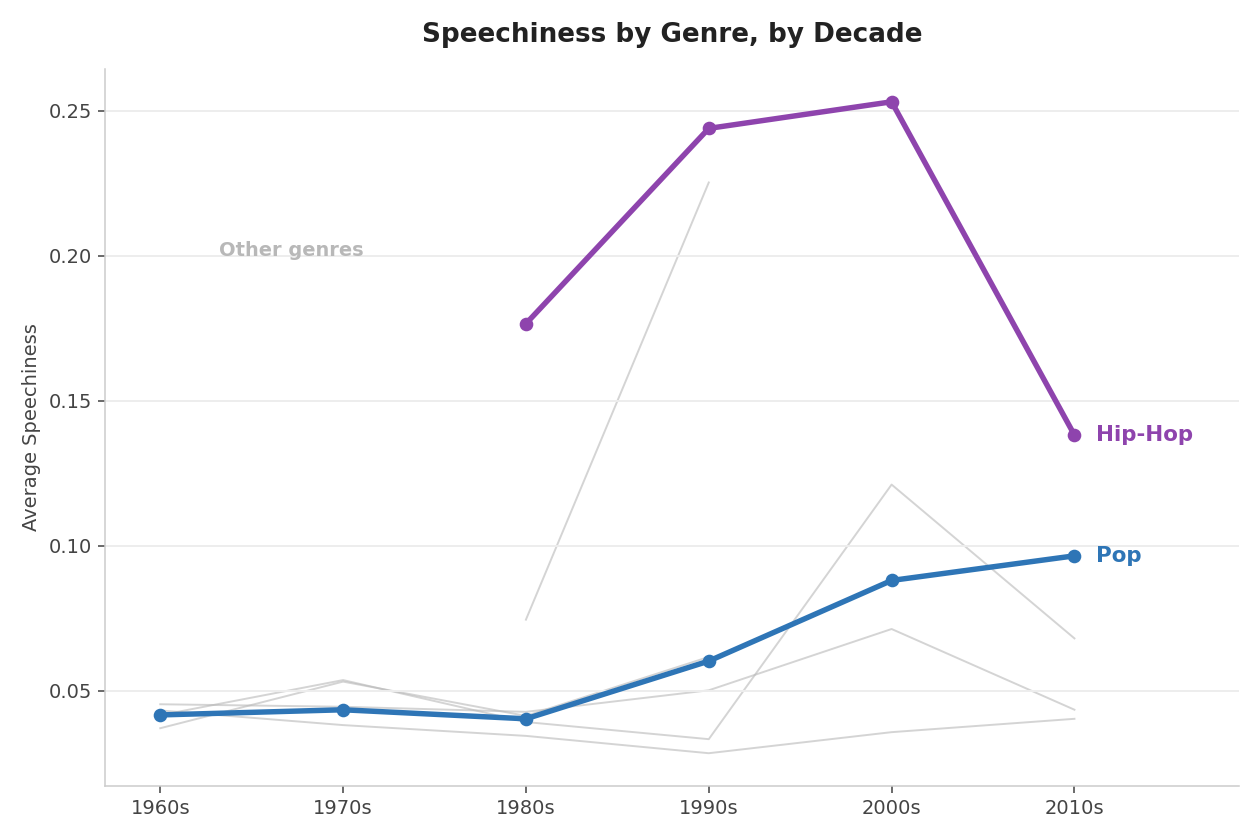

In [7]:
show("rq3_speechiness_by_genre_line.png", width=760)

Breaking Speechiness down by genre and by decade shows Pop's own trajectory clearly: 

- Pop music shows a steady climb from ~0.04 in the 1960s to ~0.098 by the 2010s.Visible as a distinct rising line well above the gray band of every other genre except Hip-Hop. **Pop itself has been growing more speech-forward across six decades**

**Caveat:** While the genre labels only cover 14–19% of the dataset, Speechiness itself is 100% complete. So even if the exact genre percentages are imperfect, the overall upward trend is 100% real

## 6. Results — RQ4: Audio Features and Chart Success

To identify which audio features are most strongly associated with chart success, this section uses two classification models on D2 (Spotify Hit Predictor), a dataset independently balanced 50/50 Hit/Flop.

- **Logistic Regression**   (explanatory: coefficients + significance) 
- **Random Forest**   (predictive strength + non-linear relationships) 

D1 (Billboard charts) contains only weekly Hot 100 charted songs. Joining D1 to D2 for this task produces a `target` distribution of 80.06% Hit, 0.06% Flop (264,281 vs. 197 rows), resulting in a dataset with essentially no negative examples to learn from. **RQ4 deliberately uses D2 alone, which was independently constructed to be 50/50 balanced, avoiding this data-leakage trap entirely.**

*(Separately verified: 99.92% of D2's Hit songs do match real Billboard chart history, and only 0.12% of D2's Flop songs do, which confirms D2's labels are trustworthy even though they can't be merged with D1 for modeling.)*

### 6.1 Model Performance

| Model | Accuracy | AUC | Sensitivity (Hit) | Specificity (Flop) |
|---|---|---|---|---|
| Logistic Regression | 0.7293 | 0.8071 | 0.8095 | 0.6490 |
| Random Forest | 0.7842 | 0.8666 | 0.8329 | 0.7356 |

- **The Random Forest model** achieved an AUC of 0.87 (or 0.867), outperforming the standard Logistic Regression model (AUC = 0.80)
- Random Forest outperforms Logistic Regression on every metric, **suggesting the relationship between audio features and chart success involves non-linear interactions**. *LR's linear formula cannot fully capture.*


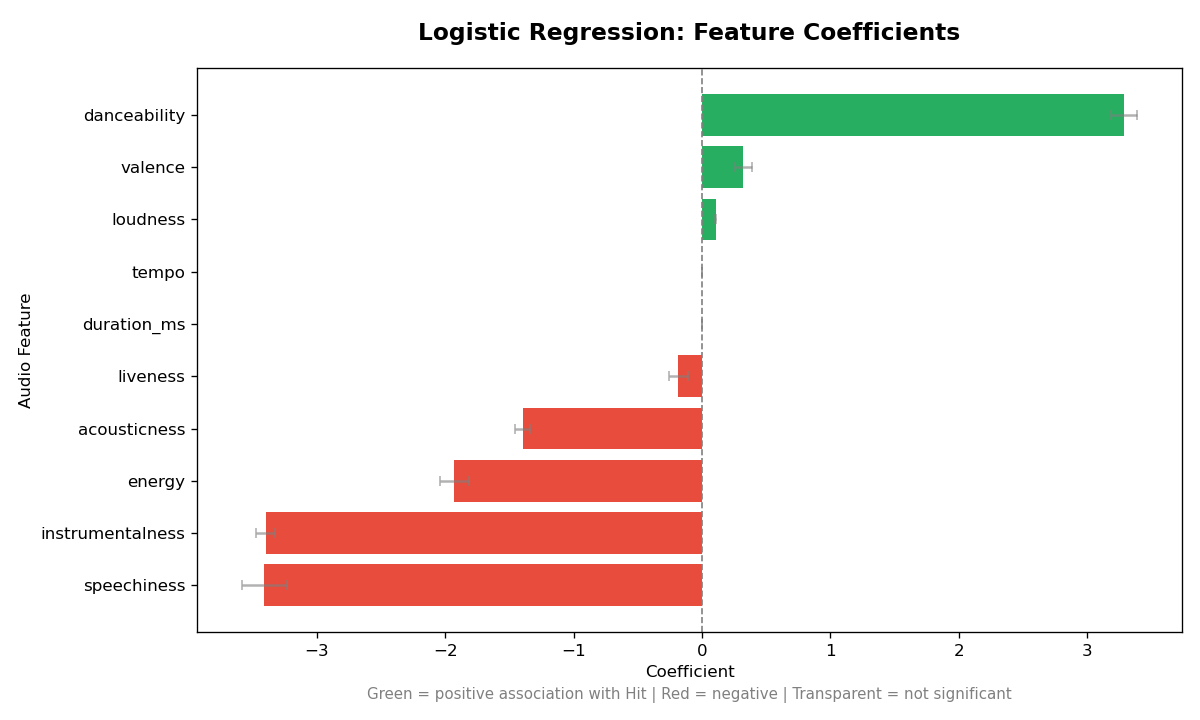
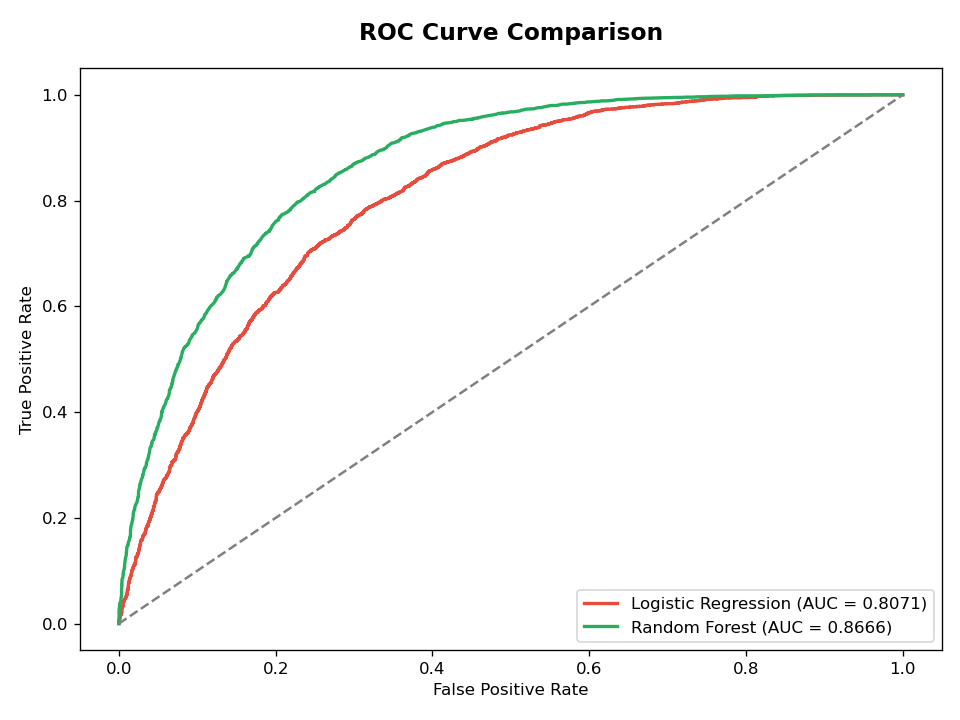

In [8]:
show_row(["rq4_lr_coefficients.png", "rq4_roc_comparison.png"])

### 6.2 Which Features Matter Most


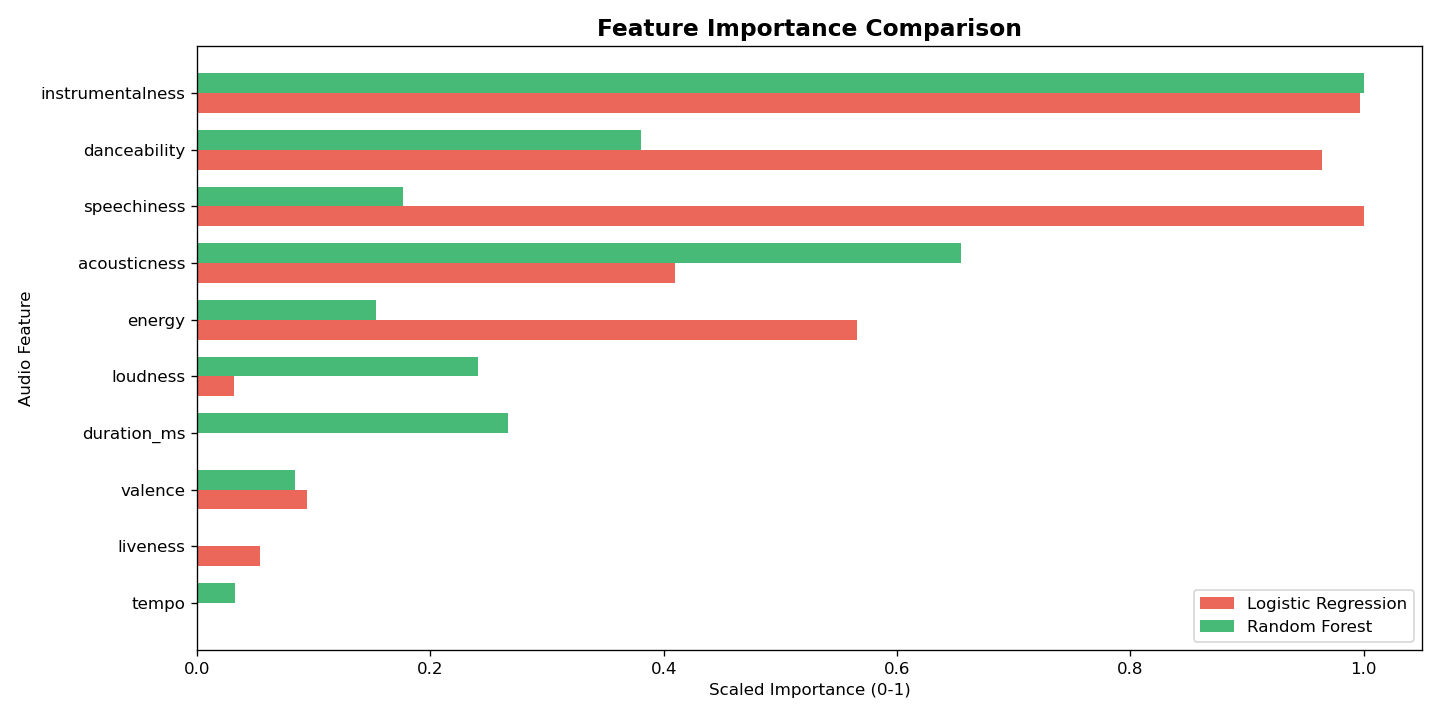

In [9]:
show("rq4_importance_comparison.png")

**Chart Note:** 

- LR importance = coefficient magnitude (linear effect)
- RF importance = permutation importance (accuracy drop when shuffled)

They are not the same scale. Agreement across both signals a robust finding; divergence signals a non-linear or interaction effect. 

> *Strong alignment across both metrics indicates high findings reliability, whereas substantial divergence signals a non-linear/interaction effect, or redundancy with a correlated feature*

Comparing key features reveals both clear model alignment and notable divergence:

**1. Agreement signals**

- **instrumentalness** (negative — vocal-absent tracks rarely chart)
- **acousticness** (negative — electronic production has displaced acoustic instrumentation)
- **danceability** (positive — Strong rhythmic drive significantly favors hit potential)

**2. Substantial divergence signals**

- **energy** and **speechiness**
    - *The reason for energy* — *Feature Redundancy* : A correlation check found energy highly correlated with loudness (r=0.773) and acousticness (r=-0.715). Its modest permutation-importance rank (despite a high Gini-importance rank) reflects redundancy, not unimportance.
    - *The reason for speechiness* — *Decade Interaction* : A decade-split check found speechiness's effect on Hit-likelihood flips — negative pre-1990, positive from the 1990s on (not redundancy: |r| ≤ 0.156). LR's single coefficient averages this reversal into insignificance; RF, without ever seeing decade directly, still partially captures it through combinations of the other features.

### 6.3 Extension: Can the Model Explain More?

The 10-feature LR model's Pseudo R² of **0.232** means these audio features explain roughly 23% of what separates a Hit from a Flop — expected for an *Explanatory*, not *Predictive*, model (see Section 7). **Two extensions** were tested to see whether this could be pushed further without new data collection:

1. **Technology era** (`pre_digital` / `digital_download` / `streaming`, derived from D2's `decade` field) — controls for the known "60 years pooled together" limitation.
2. **Interaction terms** (`danceability×energy`, `instrumentalness×acousticness`, `danceability×valence`) — Section 6.1 RF's AUC advantage over LR (0.87 vs 0.80) suggested LR was missing combination effects; these three pairs were chosen because each term individually already ranks among the most important features, they have a plausible musical rationale, and none pairs two variables already flagged as redundant in the correlation check.

    - **Instrumentalness × Acousticness:** To test whether "organic, largely-instrumental" tracks behave as one coherent musical identity.
    - **Danceability × Energy:** To test whether danceability only translates into hit potential once it's paired with enough physical intensity.
    - **Danceability × Valence:** To test whether pairing maximum danceability with maximum positivity produces a song with less distinctive character than pairing danceability with a more complex, less uniformly cheerful tone.

| Metric | Original (10 features) | Extended (+ era + interactions, 15 features) | Change |
|---|---|---|---|
| Pseudo R² | 0.2320 | 0.2544 | **+0.0224** |
| Accuracy | 0.7293 | 0.7426 | +0.0133 |
| AUC | 0.8071 | 0.8171 | +0.0100 |
| Specificity | 0.6490 | 0.6779 | **+0.0289** |


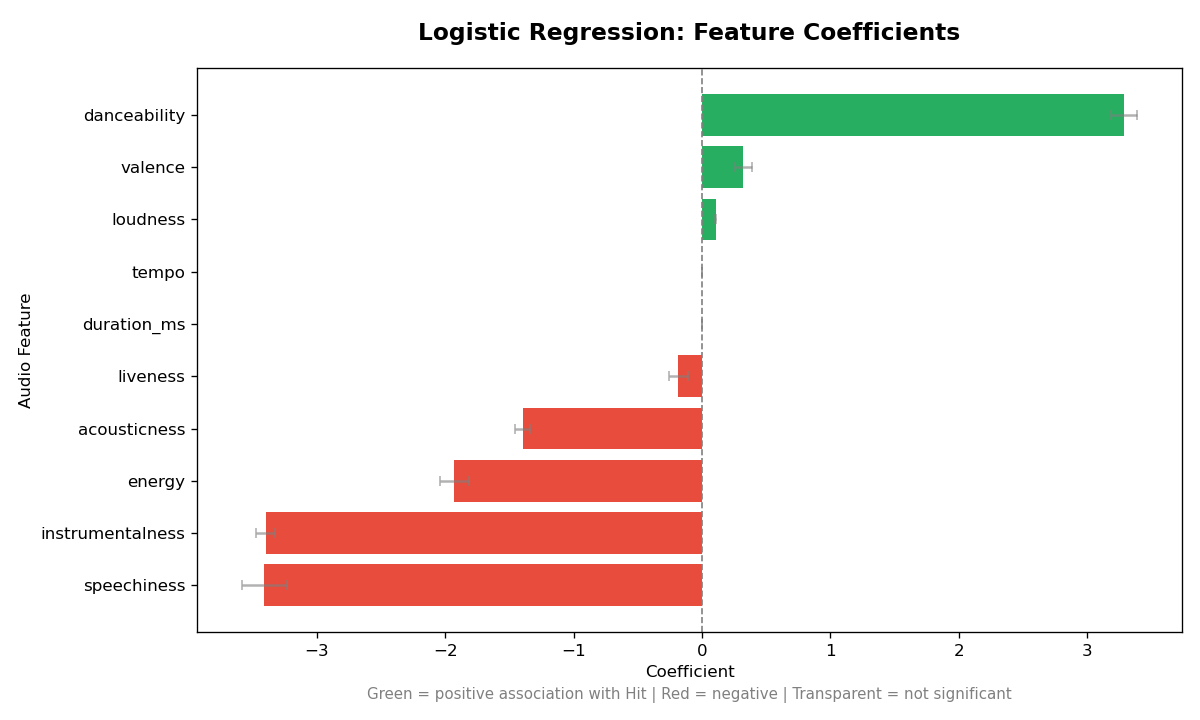
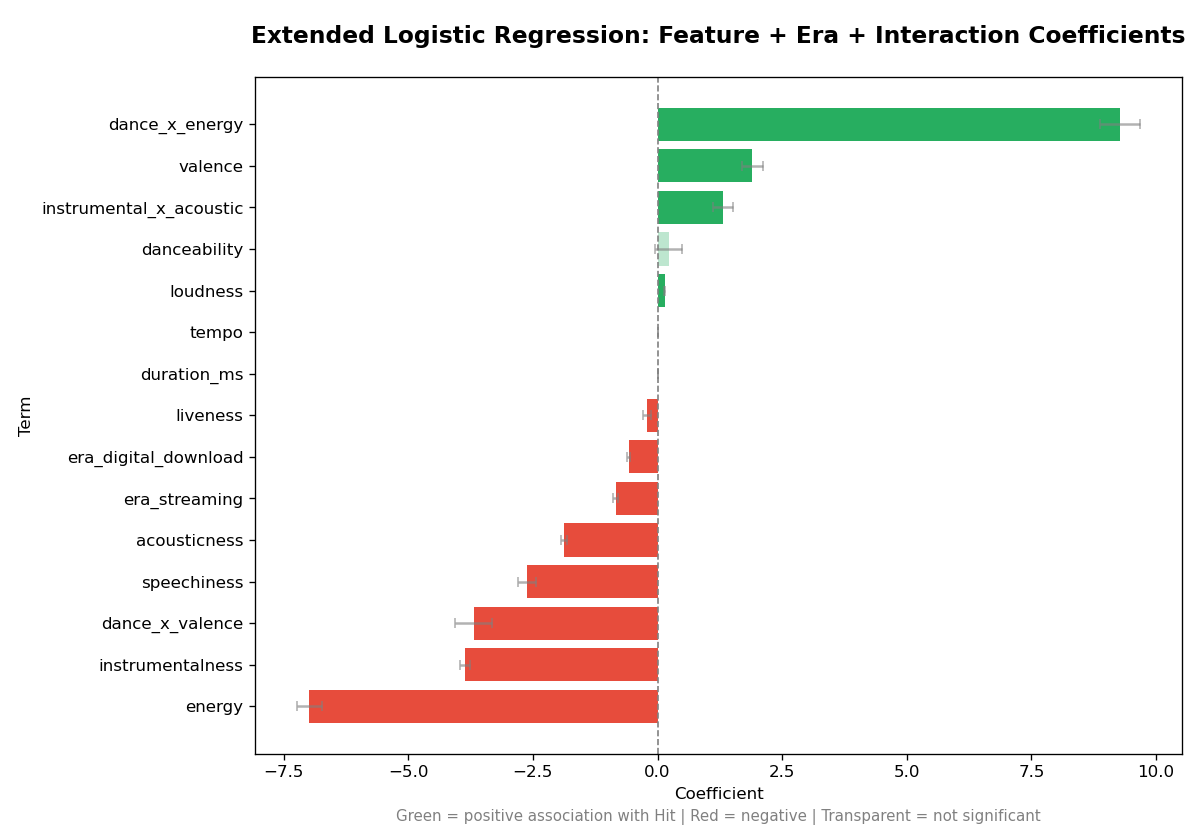

In [10]:
show_row(["rq4_lr_coefficients.png", "rq4_extended_coefficients.png"])

**Key Insight:** 

- **danceability × energy is the single strongest driver** in the extended model (+9.28) — outperforming every individual feature.
- **Standalone effect shift:**  Once interaction terms are introduced, `danceability`'s individual coefficient loses statistical significance (p=0.403). This reveals that danceability impacts hit potential almost entirely through its combined interaction with `energy` and `valence`, rather than as an isolated trait.

### 6.4 A Closer Look: Does the Model Fit Better Within a Single Era?

Section 6.3 already gave two reference points: the **10-feature** baseline, and the **15-feature** model (10 original + 2 era dummies + 3 interaction terms). This section adds two more versions, each isolating one thing:

1. **13-feature (era removed)** — the 15-feature model with the 2 era dummy columns taken out, to measure what era alone was contributing.
2. **13-feature, 2010s only** — that same 13-feature model, but retrained using **only 2010s rows** instead of all six decades pooled together, to test whether pooling six decades understates how strongly these features predict a hit *within* a single era.

**Check 1 — How much does era itself add, within the 60-year pooled data?**

| Metric | 10-feature (baseline) | 13-feature (era removed)  | 15-feature (+ era, baseline) |
|---|---|---|---|
| Pseudo R² | 0.2320 | 0.2452 | 0.2544 |
| Accuracy | 0.7293 | 0.7387 | 0.7426 |
| AUC | 0.8071 | 0.8141 | 0.8171 |

In terms of Pseudo $R^2$ improvement (+0.0224 total):

- Interaction terms (+0.0132, 59%) drive the primary gain.
- Era (+0.0092, 41%) provides a secondary, though meaningful, boost.

**Check 2 — Does the same 13-feature model fit better when trained on a single era (2010s only)?**

| Metric | 13-feature, 60-year pooled | 13-feature, 2010s only |
|---|---|---|
| Pseudo R² | 0.2452 | **0.3981** |
| Accuracy | 0.7387 | 0.8039 |
| AUC | 0.8141 | 0.8634 |

**Key Finding:**
Isolating the 2010s data yields a far stronger model fit — Pseudo $R^2$ jumps by 62% (from 0.2452 to 0.3981) and AUC reaches 0.8634, while several feature coefficients shift dramatically:

| Term | 60-year pooled | 2010s only |
|---|---|---|
| `instrumentalness × acousticness` | +0.98 | **+6.93** |
| `danceability × valence` | −3.50 | **−10.77** |
| `energy` | −6.66 | **−12.38** |
| `speechiness` | −3.19 (significant) | +0.24 (not significant, p=0.535) |

The pooled coefficients are an average across six decades that may each run on a different "hit formula" — `speechiness`'s vanishing significance within a single era lines up directly with Section 6.2's decade-interaction finding.


**A direction for a contemporary track, read from the 2010s-only coefficients:**

| Term | 2010s coefficient | Direction |
|---|---|---|
| `danceability × energy` | **+11.92** | Positive — strongest lever |
| `instrumentalness × acousticness` | +6.93 | Positive |
| `valence` (alone) | +5.72 | Positive |
| `speechiness` | +0.24 | Not significant (p=0.535) |
| `instrumentalness` (alone) | −10.02 | Negative |
| `danceability × valence` | −10.77 | Negative |


**Key Finding:**

- **Instrumental vs. Acoustic Synergy:** A `heavily instrumental` track is a steep penalty on its own (−10.02) unless paired with `genuine acoustic instrumentation` (+6.93 combined), revealing a preference for "unplugged" organic sound over electronic instrumentals.
- **Danceability & Energy Groove:** `danceability × energy` remains the single strongest lever (+11.92, even stronger than pooled), emphasizing the paramount importance of an upbeat, physically energetic groove.
- **Emotional Valence Nuance:** `valence` has an independent positive pull (+5.72), but stacking maximum positivity onto maximum danceability comes at a cost (`danceability × valence`: −10.77) — suggesting that tracks with emotional tension perform better than uniformly happy ones.
- **Speechiness Neutrality:** `speechiness` loses statistical significance within the 2010s era ($p = 0.535$), indicating that its overall historical impact was driven by cross-decade shifts rather than a universal single-era hit rule.

**Caveat:** the 2010s subset is 6,398 rows against the full 41,106 — smaller, so these coefficients carry more uncertainty than the pooled ones. The R²/AUC gains, though, were measured on genuine held-out test data, not fit statistics, so the improvement itself is not an artifact of the smaller sample.

## 7. Limitations

### 7.1 Data Coverage

<table class="table">
<colgroup>
<col style="width: 18%">
<col style="width: 82%">
</colgroup>
<thead>
<tr><th>Limitation</th><th>Description</th></tr>
</thead>
<tbody>
<tr><td>D3 genre coverage</td><td>Only 14-19% of <code>analysis_base</code> has a matched genre label, and coverage is uneven by decade — genre-specific findings (RQ1, RQ3's genre breakdown) are directional, not exact</td></tr>
<tr><td>D2 join rate</td><td>~80% of D1 records have matched Spotify audio features; ~20% of chart entries are missing this data, a possible source of selection bias</td></tr>
<tr><td>Time range</td><td>1960-2019 only, to keep consistent coverage across all three datasets</td></tr>
<tr><td>D2 date granularity</td><td>D2 has decade-level labels only, not exact release year — the Section 6.3 “technology era” feature is a decade-level approximation, not a precise pre/post-launch-date split</td></tr>
</tbody>
</table>

### 7.2 D3's Genre Field Is an Untraceable Black Box

D3's `genre` label traces back to a genre-filtered Spotify search (one query per genre, via the `spotipy` library) — not an independent, song-level classification. Two separate access points into how this actually works were checked, and both dead-end:

- **The source paper's own citation is now broken.** Its one Spotify-API reference — "for Developers., S. Get audio features for a track. Available at https://developer.spotify.com/documentation/web-api/reference/tracks/get-audio-features/" — returns **HTTP 404** as of this writing. The paper itself only states that data was fetched "using spotipy... to search for specific genres, artists, songs, release dates, etc.", with no further methodology.
- **Spotify's own current documentation doesn't fill the gap either.** It confirms a `genre` search filter can be applied to track searches, but never discloses the matching logic behind it — i.e. how a track by an artist tagged with several genres gets assigned to any one of them.

**This is a limitation of the data source itself, not an oversight of this analysis** — the mechanism cannot be traced further with what either the paper or Spotify has published.

### 7.3 Modeling Assumptions

**Temporal pooling:** Section 6.4 confirms this matters — the same model trained on 2010s data alone nearly doubles its Pseudo R² over the 60-year pooled version, and several coefficients shift sharply. The pooled model remains the report's headline result (larger sample, more stable estimates); the 2010s-only version is a directional check on one decade, not a replacement, and was not run for the other five.

**Explanatory, not predictive:** RQ4's goal is to understand historical associations, not to forecast future hits. A Pseudo R² around 0.23-0.25 means most of what separates a Hit from a Flop is not captured by audio features alone — that is an expected, not a failing, result for this kind of analysis (see 7.5).

**Label definition:** D2's Hit/Flop labels come from the dataset author's own criteria, not directly from official Billboard placement — though a direct check found 99.92% of D2's labeled Hits do match real Billboard chart history.

### 7.4 What External Data Could Not Fix

A search for additional Kaggle datasets covering marketing spend, artist popularity, or social reach (to explain the ~75% of hit-status this model cannot account for) found several genuinely useful *current* datasets — but none with historical coverage matching 1960-2019. Streaming-era metrics like YouTube views or Spotify's live `popularity` score reflect a song's standing *today*, not its marketing push or cultural reach at the time it originally charted, especially pre-1999 when no such platforms existed. **This is a real data-availability limitation, not an unexplored research direction** — no free or low-cost dataset currently bridges six decades of historical marketing data.

### 7.5 Spotify Audio Features

Valence, Energy, Speechiness, and the other audio features are estimated purely from the audio signal (rhythm, timbre, harmonic content) — they capture the *sonic* dimension of a track, not lyrical meaning or cultural context. A song can score high on Valence (musically "positive-sounding") while its lyrics convey something entirely different — this is a known limitation of the features themselves, not an error in this analysis.

**Instrumentalness and Acousticness:** these two are estimated by an undisclosed model, and can misjudge tracks with unusual vocal timbre. Spotify's own documentation defines Instrumentalness as predicting "whether a track contains no vocals... the closer the instrumentalness value is to 1.0, the greater likelihood the track contains no vocal content," and Acousticness as "a confidence measure ... of whether the track is acoustic." The detection algorithm behind these scores is not published. A documented case from [Spotify's developer community](https://community.spotify.com/t5/Spotify-for-Developers/Acousticness-and-Instrumentalness-fooled-by-Harpsichord/td-p/5347999) shows the risk directly: two purely instrumental harpsichord recordings (Bach's *Well-Tempered Clavier*, no vocals at all) scored an Instrumentalness of just 0.1, meaning the model was "quite certain" they contained vocals when they contained none.

The top 5 Billboard Hot 100 songs by combined Instrumentalness × Acousticness in `analysis_base` show the same pattern in reverse. Two are genuine, verified instrumental screen themes (*Batman Theme*, Neal Hefti, from the 1966 TV series; *(Theme From) Love Story*, Henry Mancini, from the 1970 film) and one is a genuine instrumental jazz trio recording (*Water Boy*, Don Shirley Trio). The other two, *I'm Not The Only One* (Sam Smith, peaked #5) and *You're Beautiful* (James Blunt, peaked #1), are well-known vocal ballads that score 0.93-0.96 Instrumentalness despite containing vocals throughout, consistent with the same kind of misjudgment documented above.

**The Section 8 "Acoustic Instrumentation" finding should be read as a genuine model coefficient (instrumentalness × acousticness: +6.93), illustrated with a verified example, not as proof that every high-scoring song in the underlying data is actually vocal-free.**


## 8. Conclusion

<table class="table">
<colgroup>
<col style="width: 8%">
<col style="width: 25%">
<col style="width: 67%">
</colgroup>
<thead>
<tr><th>RQ</th><th>Question</th><th>Key Finding</th></tr>
</thead>
<tbody>
<tr><td>RQ1</td><td>Genre distribution across decades?</td><td>Pop rose 61.4%→78.4%; Rock peaked 34.3% (1980s) then collapsed to 4.3%; Blues fell from 15.1% to near zero</td></tr>
<tr><td>RQ2</td><td>How has emotional tone evolved?</td><td>Valence fell ~22.6% while Energy rose — modern hits are darker but more forceful, not simply “sadder”; the social-unrest causal story does not hold up against the actual timeline</td></tr>
<tr><td>RQ3</td><td>Does speechiness reflect Hip-Hop's rise?</td><td>Speechiness Expansion: Overall speechiness rose 179.6%. While Hip-Hop drives this trend with the highest intensity (3.86× other genres), Pop itself has grown increasingly speech-forward across six decades (~0.04 in the 1960s to ~0.098 in the 2010s), showing that the shift towards rhythmic/spoken delivery spans beyond a single genre</td></tr>
<tr><td>RQ4</td><td>Which audio features predict chart success?</td><td>Historical Base &amp; Modern Shifts: Across 60 years, instrumentalness, danceability, and acousticness are the strongest hit signals, with RF (AUC 0.867) outperforming LR (AUC 0.807) due to non-linear effects. When trained on 2010s data alone, model fit nearly doubles (Pseudo R² 0.245 → 0.398). Contemporary hits favor intense, high-energy grooves (danceability × energy: +11.92), while extreme emotional cheerfulness creates a drag (danceability × valence: -10.77), showing a clear listener preference for high-impact, emotionally nuanced tracks</td></tr>
</tbody>
</table>

### For a Contemporary Track

Based on Section 6.4's 2010s-only model — which nearly doubles the explanatory power of the 60-year pooled version (Pseudo R²: 0.245 → 0.398) — a modern hit profile points to the following directional traits. Each trait is paired with a real 2010s Hit and a real 2010s Flop (per D2's own label) showing the two ends of that trait:

- **Rhythmic Energy:** Pair strong danceability with strong energy (danceability × energy: +11.92), which serves as the single strongest lever in this era.

<div style="max-width: 640px; margin-left: 1.5em;">
<table class="table">
<colgroup>
<col style="width: 20%">
<col style="width: 40%">
<col style="width: 40%">
</colgroup>
<thead>
<tr><th></th><th>Song – Artist</th><th>Value</th></tr>
</thead>
<tbody>
<tr><td>Hit example</td><td>Not Afraid – Eminem</td><td>danceability 0.86, energy 0.95</td></tr>
<tr><td>Flop example</td><td>Beneath the Remains – Sepultura</td><td>danceability 0.31, energy 1.00</td></tr>
</tbody>
</table>
</div>

- **Emotional Balance:** Keep valence positive on its own (+5.72), but avoid maxing it out alongside danceability (danceability × valence: −10.77) to maintain emotional nuance.

<div style="max-width: 640px; margin-left: 1.5em;">
<table class="table">
<colgroup>
<col style="width: 20%">
<col style="width: 40%">
<col style="width: 40%">
</colgroup>
<thead>
<tr><th></th><th>Song – Artist</th><th>Value</th></tr>
</thead>
<tbody>
<tr><td>Hit example</td><td>HUMBLE. – Kendrick Lamar</td><td>danceability 0.91, energy 0.62, valence 0.42</td></tr>
<tr><td>Flop example</td><td>Boa Me – Fuse ODG ft. Ed Sheeran &amp; Mugeez</td><td>danceability 0.91, valence 0.97</td></tr>
</tbody>
</table>
</div>

- **Acoustic Instrumentation:** If leaning instrumental, pair high instrumentalness with genuine acoustic instrumentation (+6.93) rather than an electronic-instrumental mix.

<div style="max-width: 640px; margin-left: 1.5em;">
<table class="table">
<colgroup>
<col style="width: 20%">
<col style="width: 40%">
<col style="width: 40%">
</colgroup>
<thead>
<tr><th></th><th>Song – Artist</th><th>Value</th></tr>
</thead>
<tbody>
<tr><td>Hit example</td><td>(Theme From) Love Story – Henry Mancini</td><td>instrumentalness 0.95, acousticness 0.96</td></tr>
<tr><td>Flop example</td><td>Elégie – Nocturnal Depression</td><td>instrumentalness 0.99, acousticness 0.00</td></tr>
</tbody>
</table>
</div>

- **Speechiness Impact:** Speechiness shows no reliable direction (p = 0.535) within this single era — no example table below, since illustrating a non-significant finding with a Hit/Flop pair would imply a pattern that isn't actually there.

**Note:** 

- This provides a directional read based on one decade's statistical coefficients rather than a deterministic formula; Section 7.3's caveats regarding sample size and explanatory (non-predictive) scope still apply.
- The Flop examples come from D2's own catalog, which is dominated by lesser-known/independent artists rather than "failed mainstream attempts" — they illustrate the trait's opposite extreme, not a claim that any specific artist "should have" charted.


### Broader Implications

Across all four questions, popular music's evolution reads as coherent rather than random: the rhythmic, speech-heavy aesthetic that RQ3 traces to Hip-Hop's mainstreaming helps explain part of RQ2's valence decline; the structural features that dominate RQ4's models (danceability, low instrumentalness) reflect the same genre shift RQ1 documents at the chart level. None of these four findings stand alone — they are four views of the same six-decade transition.

### Future Research Directions

- **Full decade-by-decade modeling** — Section 6.4 tested this for the 2010s alone (Pseudo R² nearly doubled, several coefficients shifted sharply); running the same per-decade model on all six decades would show whether every era has an equally strong "hit formula," or whether the 2010s result is itself unusual
- **The five unused D2 columns** (`key`, `mode`, `time_signature`, `chorus_hit`, `sections`) — available at zero additional data-collection cost, not yet tested against Pseudo R²
- **Artist-frequency proxy for fame** — derivable from D2's own `artist` field, with an explicit circularity caveat, as a low-cost alternative to the external popularity data this report could not obtain (Section 7.3)
- **International markets** — this analysis is U.S.-only; whether these trends generalize elsewhere is untested
- **Live Spotify Artist API instead of the static D3 snapshot** — would be a more current, directly-citable genre source than a 2022 Kaggle file, and the basic Get Artist endpoint (unlike Audio Features/Recommendations/Related Artists) is not on Spotify's Nov 2024 restricted-endpoint list, so it remains accessible. Two limits carry over regardless of data freshness, though: genre attaches to the *artist* object, not the *track*, and is frequently multi-valued with no indicator of which tag applies to any specific song (Spotify's own documented example: `"genres": ["Prog rock", "Grunge"]`) — an artist active across eras or styles offers no way to resolve which label fits *this* song, so this ambiguity would persist even with 100% coverage